# Statistical Methods in Imaging (SMI) Conference, 2026.
# Empowering Large Language Models with Statistics: A Practical Tutorial for Medical Imaging
**Ernest (Khashayar) Namdar, Dominik A. Deniffel, Pascal Tyrrell**

This tutorial focuses on classifying Acute Ischemic Stroke (AIS) from Radiology reports.
In this notebook, we load the predictions from all 6 pipelines we built (4 from Part 1, and 2 from Part 2), compute the per-fold ROC-AUC scores, and perform statistical comparisons.

Several similar pipelines were discussed in our publication:
```bibtex
@inproceedings{10.1117/12.3084682,
author = {Khashayar Namdar and Saeidehsadat Mirjalili and Lauren Erdman and Dominik A. Deniffel and Keith Brunt and Leo Anthony Celi},
title = {{Comparative evaluation of machine learning and large language model pipelines for identifying acute ischemic stroke in radiology reports}},
volume = {13926},
booktitle = {Medical Imaging 2026: Computer-Aided Diagnosis},
editor = {Axel Wism{\"u}ller and Thomas Martin Deserno},
organization = {International Society for Optics and Photonics},
publisher = {SPIE},
pages = {139261S},
keywords = {Stroke, NLP, Machine Learning, Large Language Models},
year = {2026},
doi = {10.1117/12.3084682},
URL = {https://doi.org/10.1117/12.3084682}
}
```


## 1. Load Data and Compute Per-Fold AUC
We load `Folds.csv` to ensure exactly the same cohorts are evaluated for every model. We also calculate the Ensemble predictor by taking the simple average of the three Part 1 models.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Load ground truth and folds
folds = pd.read_csv('../../Part1_Encoder_LLM_for_Classification/data/Folds.csv')
ais = pd.read_csv('../data/AIS.csv')[['ID', 'Label']]

# Load predictions from Part 1
pred_lgb = pd.read_csv('../../Part1_Encoder_LLM_for_Classification/results/predictions.csv')[['ID', 'predictions']].rename(columns={'predictions': 'LGB_Prob'})
pred_tfidf = pd.read_csv('../../Part1_Encoder_LLM_for_Classification/results/predictions_tfidf.csv')[['ID', 'predictions']].rename(columns={'predictions': 'TFIDF_Prob'})
pred_rf = pd.read_csv('../../Part1_Encoder_LLM_for_Classification/results/predictions_rf.csv')[['ID', 'predictions']].rename(columns={'predictions': 'RF_Prob'})

# Load predictions from Part 2
pred_lm_prob = pd.read_csv('../results/LM_prob_inference.csv')[['Id', 'Prob_Yes']].rename(columns={'Id': 'ID', 'Prob_Yes': 'LM_Prob'})
pred_lm_pydantic = pd.read_csv('../results/LM_pydantic_inference.csv')[['Id', 'Prob_Yes']].rename(columns={'Id': 'ID', 'Prob_Yes': 'LM_Pydantic_Prob'})

# Merge all datasets on ID
df = folds.merge(ais, on='ID')
df = df.merge(pred_lgb, on='ID')
df = df.merge(pred_tfidf, on='ID')
df = df.merge(pred_rf, on='ID')
df = df.merge(pred_lm_prob, on='ID', how='left')
df = df.merge(pred_lm_pydantic, on='ID', how='left')

# Calculate Ensemble Probability (Simple averaging of the three encoder-based models)
df['Ensemble_Prob'] = (df['LGB_Prob'] + df['TFIDF_Prob'] + df['RF_Prob']) / 3.0

pipelines = ['LGB_Prob', 'TFIDF_Prob', 'RF_Prob', 'Ensemble_Prob', 'LM_Prob', 'LM_Pydantic_Prob']

aucs = {p: [] for p in pipelines}

# Drop any rows with missing predictions to ensure fair comparison
df_clean = df.dropna(subset=pipelines)

for fold in sorted(df_clean['Fold'].unique()):
    fold_data = df_clean[df_clean['Fold'] == fold]
    y_true = fold_data['Label']
    
    if len(y_true.unique()) > 1:
        for p in pipelines:
            aucs[p].append(roc_auc_score(y_true, fold_data[p]))

auc_df = pd.DataFrame(aucs)
print("Mean AUCs Across Folds:")
print(auc_df.mean().sort_values(ascending=False))


## 2. Statistical Analysis: Paired T-Tests
> **Why a Paired T-Test?**
> Because we are evaluating the performance of every pipeline on the *exact same set of 10 cross-validation folds*, the resulting AUC scores are paired. Using a paired sample t-test (`scipy.stats.ttest_rel`) controls for the fold-to-fold variance (i.e. some folds being inherently harder or easier to predict than others), allowing us to directly measure the statistical significance of the differences in model performance.

In [ ]:
# Initialize P-values dataframe
p_values = pd.DataFrame(index=pipelines, columns=pipelines, dtype=float)

for p1 in pipelines:
    for p2 in pipelines:
        if p1 == p2:
            p_values.loc[p1, p2] = 1.0
        else:
            # We use a PAIRED t-test (ttest_rel) because all pipelines are evaluated on the exact same cross-validation folds.
            stat, p = stats.ttest_rel(auc_df[p1], auc_df[p2])
            p_values.loc[p1, p2] = p

print("Paired T-Test P-Values Calculated.")


## 3. Visualization
Below, we visualize the P-values to easily spot significant differences ($p < 0.05$), and provide boxplots of the AUC distributions.

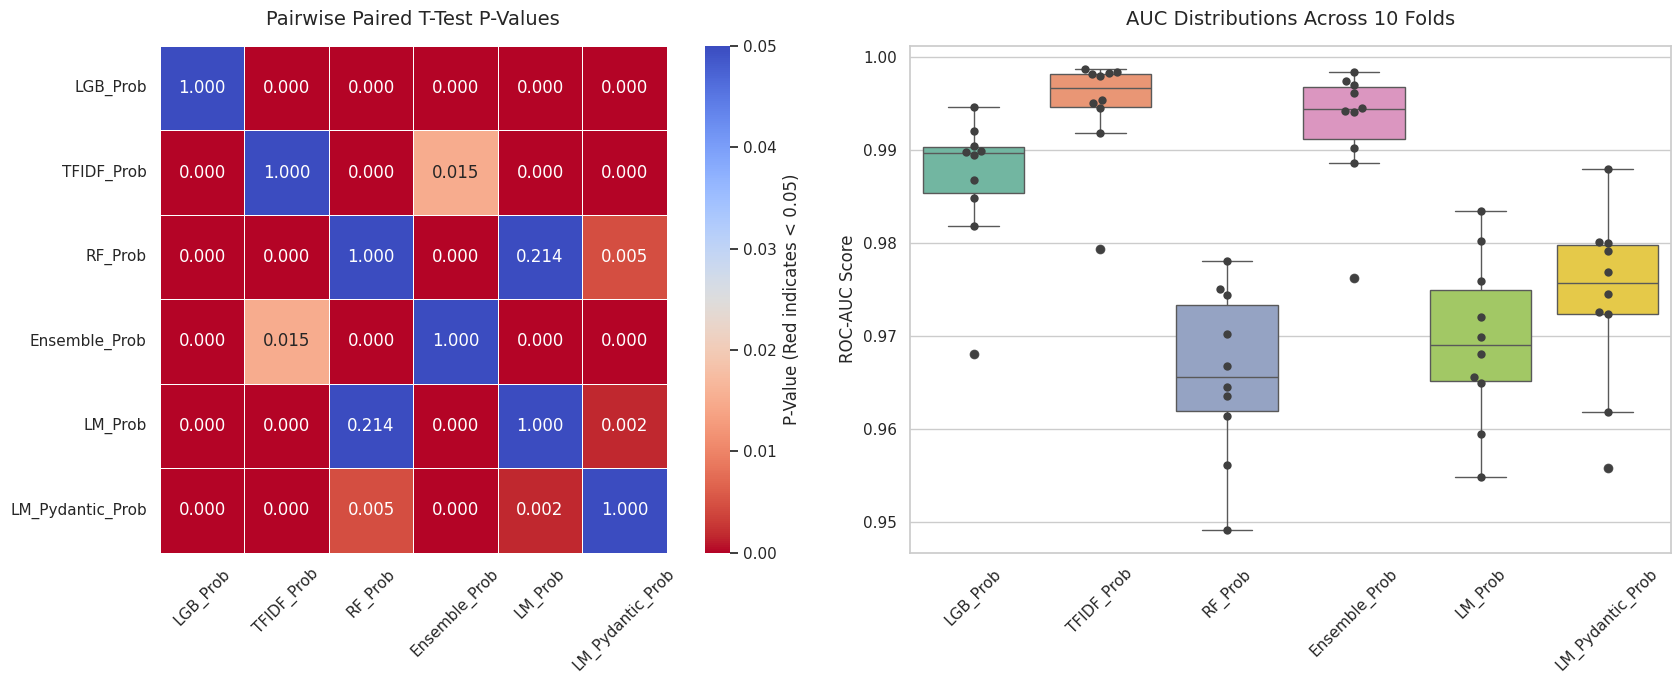

In [7]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ------------------------
# Plot 1: P-Value Heatmap
# ------------------------
# We cap the color map at 0.05 so anything significant is clearly distinguished
sns.heatmap(p_values, annot=True, fmt=".3f", cmap="coolwarm_r", vmin=0, vmax=0.05, 
            cbar_kws={'label': 'P-Value (Red indicates < 0.05)'}, ax=axes[0], linewidths=.5, square=True)
axes[0].set_title('Pairwise Paired T-Test P-Values', fontsize=14, pad=15)
axes[0].tick_params(axis='x', rotation=45)

# ------------------------
# Plot 2: AUC Boxplots
# ------------------------
sns.boxplot(data=auc_df, ax=axes[1], palette="Set2")
sns.swarmplot(data=auc_df, ax=axes[1], color=".25", size=6) # Add points to show the exact fold AUCs
axes[1].set_title('AUC Distributions Across 10 Folds', fontsize=14, pad=15)
axes[1].set_ylabel('ROC-AUC Score', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
